# Tech Skills Index

## Objectif

Le Tech Skills Index classe les compétences selon deux dimensions :

- leur fréquence dans les offres ;
- le niveau de salaire associé aux offres qui les mentionnent.

L'indice ne mesure pas un effet causal sur le salaire. Il fournit une synthèse descriptive du marché observé.

## 1. Imports

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Chargement des données

In [6]:
DATA_PATH = Path("competences_offres.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Le fichier competences_offres.csv est introuvable."
    )

skills_long = pd.read_csv(
    DATA_PATH,
    encoding="utf-8-sig",
)

required_columns = {
    "id",
    "competence",
    "famille_competence",
    "salaire_moy",
}

missing_columns = required_columns.difference(
    skills_long.columns
)

if missing_columns:
    missing_list = ", ".join(sorted(missing_columns))
    raise ValueError(f"Colonnes manquantes : {missing_list}")

skills_long["salaire_moy"] = pd.to_numeric(
    skills_long["salaire_moy"],
    errors="coerce",
)

print(
    f"Relations offre-compétence : "
    f"{len(skills_long):,}"
)
print(
    f"Compétences distinctes : "
    f"{skills_long['competence'].nunique():,}"
)

Relations offre-compétence : 3,516
Compétences distinctes : 60


## 3. Statistiques par compétence

In [9]:
skill_index = (
    skills_long
    .groupby(
        [
            "competence",
            "famille_competence",
        ]
    )
    .agg(
        nombre_offres=("id", "nunique"),
        nombre_offres_salaire=(
            "salaire_moy",
            "count",
        ),
        salaire_median=(
            "salaire_moy",
            "median",
        ),
        salaire_moyen=(
            "salaire_moy",
            "mean",
        ),
    )
    .reset_index()
)

total_offers = skills_long["id"].nunique()

skill_index["part_offres"] = (
    skill_index["nombre_offres"]
    / total_offers
    * 100
)

skill_index = skill_index.sort_values(
    "nombre_offres",
    ascending=False,
).reset_index(drop=True)

skill_index.head(10)

,competence,famille_competence,nombre_offres,nombre_offres_salaire,salaire_median,salaire_moyen,part_offres
0,SQL,Bases de données,331,98,45000.0,44255.020408,45.844875
1,Python,Langages,325,80,45000.0,45731.250000,45.013850
2,Machine Learning,Machine Learning,239,39,45000.0,46253.846154,33.102493
3,Power BI,BI et visualisation,208,60,45000.0,43729.700000,28.808864
4,Agile / Scrum,Méthodes,153,32,49000.0,46062.500000,21.191136
5,Azure,Cloud,125,32,45000.0,46468.750000,17.313019
6,CI/CD,DevOps,118,20,50000.0,48100.000000,16.343490
7,ETL / ELT,Data Engineering,112,36,42500.0,45017.500000,15.512465
8,Spark,Data Engineering,109,26,50000.0,48942.307692,15.096953
9,GCP,Cloud,106,22,47500.0,47363.636364,14.681440


## 4. Calcul des scores

Le score final combine :

- **70 % de demande** : position de la compétence dans le classement par fréquence ;
- **30 % de rémunération** : position dans le classement salarial.

Le score salarial est rapproché d'une valeur neutre lorsque peu d'offres indiquent un salaire. Cette correction réduit l'influence des petits échantillons.

In [13]:
MINIMUM_SALARY_SAMPLE = 5
FULL_RELIABILITY_SAMPLE = 30

skill_index["score_demande"] = (
    skill_index["nombre_offres"]
    .rank(
        method="average",
        pct=True,
    )
    * 100
)

salary_is_available = (
    skill_index["nombre_offres_salaire"]
    >= MINIMUM_SALARY_SAMPLE
)

skill_index["score_salaire"] = np.nan

skill_index.loc[
    salary_is_available,
    "score_salaire",
] = (
    skill_index.loc[
        salary_is_available,
        "salaire_median",
    ]
    .rank(
        method="average",
        pct=True,
    )
    * 100
)

skill_index["fiabilite_salaire"] = (
    skill_index["nombre_offres_salaire"]
    / FULL_RELIABILITY_SAMPLE
).clip(
    lower=0,
    upper=1,
)

neutral_salary_score = 50

skill_index["score_salaire_ajuste"] = (
    neutral_salary_score
    + skill_index["fiabilite_salaire"]
    * (
        skill_index["score_salaire"]
        .fillna(neutral_salary_score)
        - neutral_salary_score
    )
)

skill_index["tech_skills_index"] = (
    0.70 * skill_index["score_demande"]
    + 0.30 * skill_index["score_salaire_ajuste"]
)

skill_index["tech_skills_index"] = (
    skill_index["tech_skills_index"]
    .round(1)
)

skill_index = skill_index.sort_values(
    "tech_skills_index",
    ascending=False,
).reset_index(drop=True)



skill_index.head(20)

,competence,famille_competence,nombre_offres,nombre_offres_salaire,salaire_median,salaire_moyen,part_offres,score_demande,score_salaire,fiabilite_salaire,score_salaire_ajuste,tech_skills_index
0,Agile / Scrum,Méthodes,153,32,49000.0,46062.500000,21.191136,93.333333,74.418605,1.000000,74.418605,87.7
1,CI/CD,DevOps,118,20,50000.0,48100.000000,16.343490,90.000000,88.372093,0.666667,75.581395,85.7
2,Spark,Data Engineering,109,26,50000.0,48942.307692,15.096953,86.666667,88.372093,0.866667,83.255814,85.6
3,SQL,Bases de données,331,98,45000.0,44255.020408,45.844875,100.000000,51.162791,1.000000,51.162791,85.3
4,Python,Langages,325,80,45000.0,45731.250000,45.013850,98.333333,51.162791,1.000000,51.162791,84.2
5,Machine Learning,Machine Learning,239,39,45000.0,46253.846154,33.102493,96.666667,51.162791,1.000000,51.162791,83.0
6,Power BI,BI et visualisation,208,60,45000.0,43729.700000,28.808864,95.000000,51.162791,1.000000,51.162791,81.8
7,Azure,Cloud,125,32,45000.0,46468.750000,17.313019,91.666667,51.162791,1.000000,51.162791,79.5
8,GCP,Cloud,106,22,47500.0,47363.636364,14.681440,85.000000,69.767442,0.733333,64.496124,78.8
9,Data Warehouse,Data Engineering,70,25,50000.0,45431.600000,9.695291,76.666667,88.372093,0.833333,81.976744,78.3


## 5. Niveau de priorité

In [16]:
def assign_priority(score):
    if score >= 75:
        return "Priorité forte"

    if score >= 50:
        return "Priorité intermédiaire"

    return "Priorité faible"


skill_index["niveau_priorite"] = (
    skill_index["tech_skills_index"]
    .apply(assign_priority)
)

TRANSVERSAL_SKILLS = {
    "Agile / Scrum",
}

skill_index["type_competence"] = np.where(
    skill_index["competence"].isin(TRANSVERSAL_SKILLS),
    "Transversale",
    "Technique",
)

technical_skill_index = skill_index[
    skill_index["type_competence"] == "Technique"
].copy()

transversal_skill_index = skill_index[
    skill_index["type_competence"] == "Transversale"
].copy()

skill_index[
    [
        "competence",
        "famille_competence",
        "nombre_offres",
        "salaire_median",
        "nombre_offres_salaire",
        "tech_skills_index",
        "niveau_priorite",
    ]
].head(20)

,competence,famille_competence,nombre_offres,salaire_median,nombre_offres_salaire,tech_skills_index,niveau_priorite
0,Agile / Scrum,Méthodes,153,49000.0,32,87.7,Priorité forte
1,CI/CD,DevOps,118,50000.0,20,85.7,Priorité forte
2,Spark,Data Engineering,109,50000.0,26,85.6,Priorité forte
3,SQL,Bases de données,331,45000.0,98,85.3,Priorité forte
4,Python,Langages,325,45000.0,80,84.2,Priorité forte
5,Machine Learning,Machine Learning,239,45000.0,39,83.0,Priorité forte
6,Power BI,BI et visualisation,208,45000.0,60,81.8,Priorité forte
7,Azure,Cloud,125,45000.0,32,79.5,Priorité forte
8,GCP,Cloud,106,47500.0,22,78.8,Priorité forte
9,Data Warehouse,Data Engineering,70,50000.0,25,78.3,Priorité forte


## 6. Classement technique

Le classement principal exclut les compétences transversales afin de comparer uniquement les technologies, langages, outils et méthodes techniques.

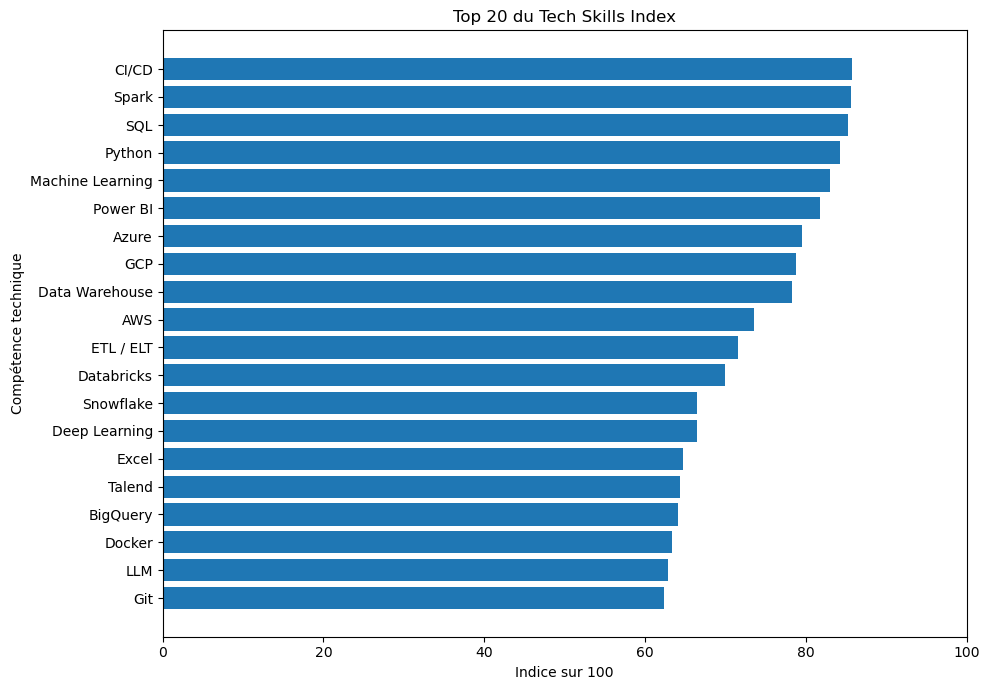

In [19]:
top_index = (
    technical_skill_index
    .head(20)
    .sort_values("tech_skills_index")
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_index["competence"],
    top_index["tech_skills_index"],
)
plt.title("Top 20 du Tech Skills Index")
plt.xlabel("Indice sur 100")
plt.ylabel("Compétence technique")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## 7. Compétences transversales

Les compétences transversales sont analysées séparément, car elles ne représentent pas une technologie ou un outil technique.

In [22]:
transversal_skill_index[
    [
        "competence",
        "nombre_offres",
        "part_offres",
        "salaire_median",
        "nombre_offres_salaire",
        "tech_skills_index",
        "niveau_priorite",
    ]
]

,competence,nombre_offres,part_offres,salaire_median,nombre_offres_salaire,tech_skills_index,niveau_priorite
0,Agile / Scrum,153,21.191136,49000.0,32,87.7,Priorité forte


## 8. Demande et rémunération

/var/folders/v4/mq90pf9s04g995xgrt9dp8qh0000gn/T/ipykernel_10237/2576383448.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  scatter_data = technical_skill_index[


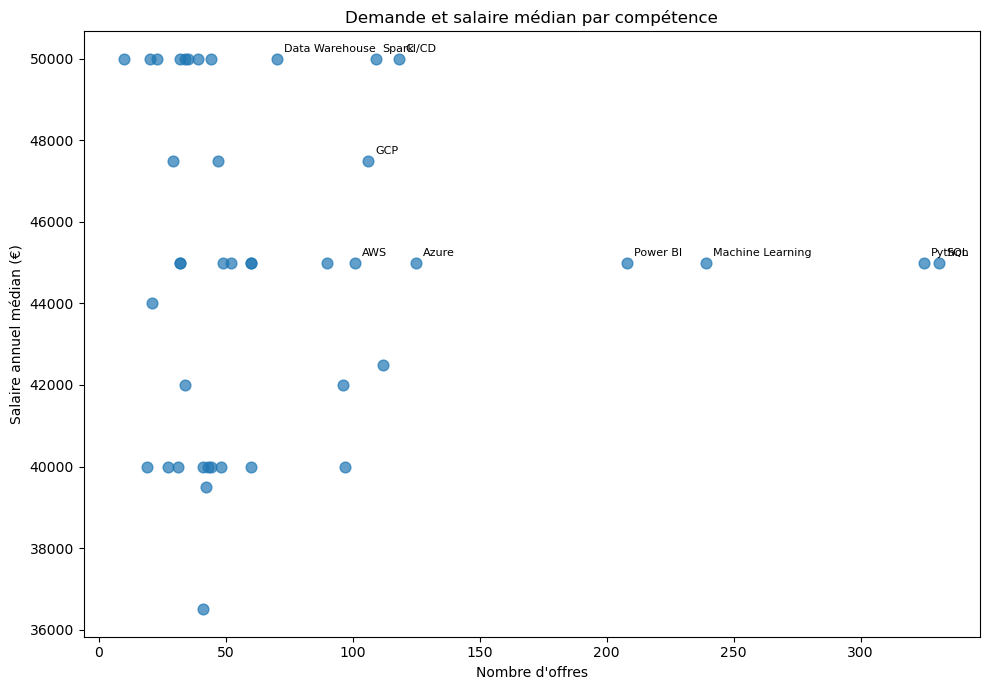

In [25]:
scatter_data = technical_skill_index[
    skill_index["nombre_offres_salaire"]
    >= MINIMUM_SALARY_SAMPLE
].copy()

plt.figure(figsize=(10, 7))
plt.scatter(
    scatter_data["nombre_offres"],
    scatter_data["salaire_median"],
    s=60,
    alpha=0.7,
)

top_labels = (
    scatter_data
    .sort_values(
        "tech_skills_index",
        ascending=False,
    )
    .head(10)
)

for _, row in top_labels.iterrows():
    plt.annotate(
        row["competence"],
        (
            row["nombre_offres"],
            row["salaire_median"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )

plt.title(
    "Demande et salaire médian "
    "par compétence"
)
plt.xlabel("Nombre d'offres")
plt.ylabel("Salaire annuel médian (€)")
plt.tight_layout()
plt.show()

## 9. Compétences techniques par profil

In [28]:
priority_by_family = (
    technical_skill_index[
        skill_index["niveau_priorite"]
        != "Priorité faible"
    ]
    .sort_values(
        [
            "famille_competence",
            "tech_skills_index",
        ],
        ascending=[True, False],
    )
    .groupby("famille_competence")
    .head(5)
    .reset_index(drop=True)
)

priority_by_family[
    [
        "famille_competence",
        "competence",
        "nombre_offres",
        "salaire_median",
        "tech_skills_index",
        "niveau_priorite",
    ]
]

/var/folders/v4/mq90pf9s04g995xgrt9dp8qh0000gn/T/ipykernel_10237/1221998234.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  technical_skill_index[


,famille_competence,competence,nombre_offres,salaire_median,tech_skills_index,niveau_priorite
0,BI et visualisation,Power BI,208,45000.0,81.8,Priorité forte
1,BI et visualisation,Excel,96,42000.0,64.7,Priorité intermédiaire
2,Bases de données,SQL,331,45000.0,85.3,Priorité forte
3,Bases de données,Snowflake,60,45000.0,66.5,Priorité intermédiaire
4,Bases de données,BigQuery,47,47500.0,64.1,Priorité intermédiaire
5,Bases de données,NoSQL,35,50000.0,55.0,Priorité intermédiaire
6,Bases de données,PostgreSQL,44,40000.0,53.7,Priorité intermédiaire
7,Cloud,Azure,125,45000.0,79.5,Priorité forte
8,Cloud,GCP,106,47500.0,78.8,Priorité forte
9,Cloud,AWS,101,45000.0,73.6,Priorité intermédiaire


## 10. Contrôle de la fiabilité

In [31]:
def reliability_label(sample_size):
    if sample_size >= 30:
        return "Bonne"

    if sample_size >= 10:
        return "Moyenne"

    if sample_size >= 5:
        return "Faible"

    return "Insuffisante"


skill_index["fiabilite_libelle"] = (
    skill_index["nombre_offres_salaire"]
    .apply(reliability_label)
)

skill_index[
    [
        "competence",
        "nombre_offres",
        "nombre_offres_salaire",
        "salaire_median",
        "fiabilite_libelle",
        "tech_skills_index",
    ]
].head(25)

,competence,nombre_offres,nombre_offres_salaire,salaire_median,fiabilite_libelle,tech_skills_index
0,Agile / Scrum,153,32,49000.0,Bonne,87.7
1,CI/CD,118,20,50000.0,Moyenne,85.7
2,Spark,109,26,50000.0,Moyenne,85.6
3,SQL,331,98,45000.0,Bonne,85.3
4,Python,325,80,45000.0,Bonne,84.2
5,Machine Learning,239,39,45000.0,Bonne,83.0
6,Power BI,208,60,45000.0,Bonne,81.8
7,Azure,125,32,45000.0,Bonne,79.5
8,GCP,106,22,47500.0,Moyenne,78.8
9,Data Warehouse,70,25,50000.0,Moyenne,78.3


## 11. Export

In [34]:
OUTPUT_PATH = Path("tech_skills_index.csv")

skill_index.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(f"Fichier sauvegardé : {OUTPUT_PATH}")

Fichier sauvegardé : tech_skills_index.csv


## Conclusion

Le Tech Skills Index met en avant les compétences techniques qui combinent une forte présence dans les offres et un niveau de rémunération favorable.

Les compétences transversales sont présentées séparément pour éviter de les comparer directement aux langages, plateformes et outils techniques.

L'indice doit rester interprété avec prudence :

- une association salariale ne prouve pas qu'une compétence augmente directement le salaire ;
- les compétences apparaissent souvent ensemble dans une même offre ;
- les résultats salariaux sont moins fiables lorsque l'échantillon est faible ;
- le classement dépend du périmètre et de la période de collecte.